Using device: cuda

Loading dataset...
Label Mapping:
0 -> Anxiety
1 -> Depression
2 -> Normal
3 -> Suicidal

Loading regression checkpoint...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: ./hf_models\roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Checkpoint loaded successfully.

Running inference...


100%|██████████████████████████████████████████████████████████████████████████████| 233/233 [00:22<00:00, 10.27it/s]



Calibration Metrics
Brier Score: 0.117546
ECE Score:   0.152034


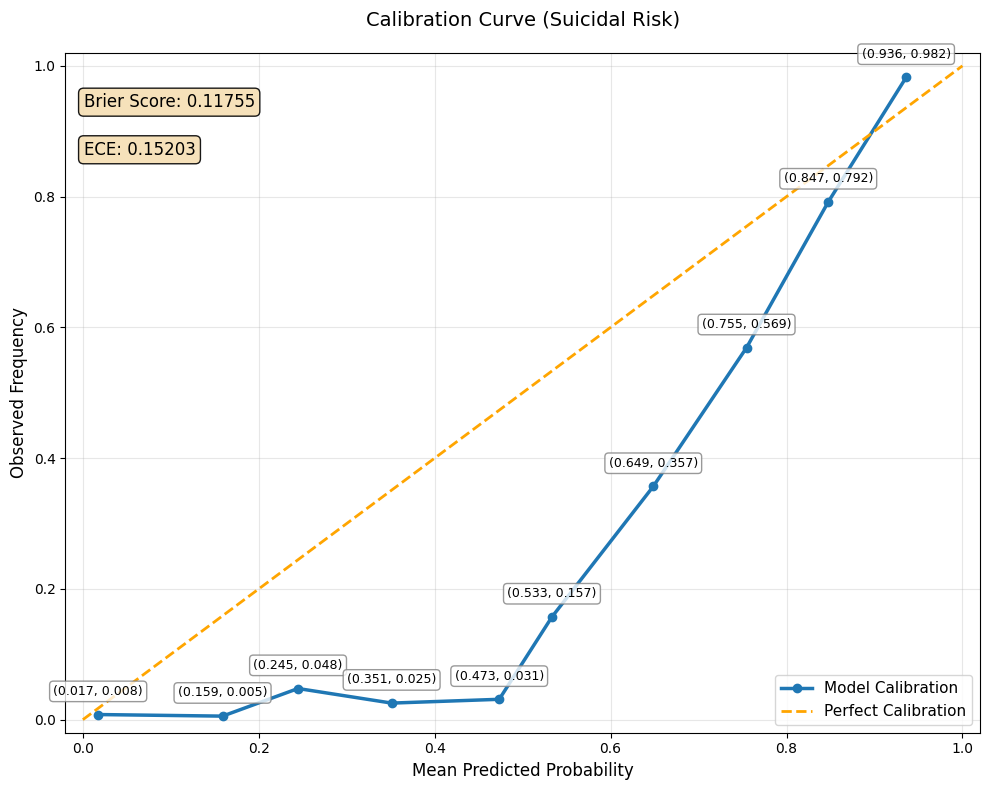

Saved: calibration_curve_annotated.png 
Saved: confidence_histogram.png
Saved: calibration_results.txt

Experiment 2 completed successfully.


In [1]:
# =========================================================
# Calibration Curve / Reliability Diagram
#
# Purpose:
# Verify whether suicidal-risk probability produced by
# regression model is reliable and clinically trustworthy
#
# Output:
# 1. Calibration Curve
# 2. Brier Score
# 3. Expected Calibration Error (ECE)
# 4. Reliability Diagram
# 5. confidence histogram
#
# Required:
# best_dual_regression.pt
#
# =========================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import os
import random
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")


# =========================================================
# Random Seed
# =========================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


# =========================================================
# Device
# =========================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


# =========================================================
# Path Config
# =========================================================

LOCAL_MODEL_DIR = "./hf_models"
MODEL_PATH = os.path.join(LOCAL_MODEL_DIR, "roberta-base")
CHECKPOINT_PATH = "best_dual_regression.pt"


# =========================================================
# Load Dataset
# =========================================================

print("\nLoading dataset...")

df = pd.read_csv("mental_heath_unbanlanced.csv")
df = df.dropna(subset=["text", "status"])
df["text"] = df["text"].astype(str)

label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df["status"])

print("Label Mapping:")
for i, name in enumerate(label_encoder.classes_):
    print(f"{i} -> {name}")


# =========================================================
# Train / Val / Test Split
# =========================================================

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["text"].tolist(),
    df["label_encoded"].tolist(),
    test_size=0.3,
    random_state=42,
    stratify=df["label_encoded"]
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)


# =========================================================
# Dataset
# =========================================================

class RiskRegressionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=96):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


# =========================================================
# Dual Regression Model
# =========================================================

class DualRegressionModel(nn.Module):
    def __init__(self, model_path):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(
            model_path,
            local_files_only=True
        )

        hidden = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(0.1)

        self.dep_head = nn.Linear(hidden, 1)
        self.sui_head = nn.Linear(hidden, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls = outputs.last_hidden_state[:, 0, :]
        cls = self.dropout(cls)

        dep_score = torch.sigmoid(
            self.dep_head(cls)
        ).squeeze(-1)

        sui_score = torch.sigmoid(
            self.sui_head(cls)
        ).squeeze(-1)

        return {
            "dep_score": dep_score,
            "sui_score": sui_score
        }


# =========================================================
# Expected Calibration Error (ECE)
# =========================================================

def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1

    ece = 0.0

    for i in range(n_bins):
        mask = binids == i

        if np.sum(mask) > 0:
            bin_acc = np.mean(y_true[mask])
            bin_conf = np.mean(y_prob[mask])

            ece += (
                np.sum(mask) / len(y_true)
            ) * abs(bin_acc - bin_conf)

    return ece


# =========================================================
# Load Model
# =========================================================

print("\nLoading regression checkpoint...")

model = DualRegressionModel(MODEL_PATH).to(DEVICE)

model.load_state_dict(
    torch.load(
        CHECKPOINT_PATH,
        map_location=DEVICE
    )
)

model.eval()

print("Checkpoint loaded successfully.")


# =========================================================
# Tokenizer + Test Loader
# =========================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    local_files_only=True
)

max_length = 96

test_dataset = RiskRegressionDataset(
    test_texts,
    test_labels,
    tokenizer
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


# =========================================================
# Inference
# =========================================================

print("\nRunning inference...")

all_sui_scores = []
all_true_binary = []

with torch.no_grad():
    for batch in tqdm(test_loader):

        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].numpy()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        sui_scores = outputs["sui_score"].cpu().numpy()

        all_sui_scores.extend(sui_scores)

        # suicidal = positive class
        binary_labels = (labels == 3).astype(int)
        all_true_binary.extend(binary_labels)


all_sui_scores = np.array(all_sui_scores)
all_true_binary = np.array(all_true_binary)


# =========================================================
# Metrics
# =========================================================

print("\n====================================================")
print("Calibration Metrics")
print("====================================================")

brier = brier_score_loss(
    all_true_binary,
    all_sui_scores
)

ece = compute_ece(
    all_true_binary,
    all_sui_scores,
    n_bins=10
)

print(f"Brier Score: {brier:.6f}")
print(f"ECE Score:   {ece:.6f}")


# =========================================================
# Calibration Curve
# =========================================================

prob_true, prob_pred = calibration_curve(
    all_true_binary,
    all_sui_scores,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(10, 8))

# 绘制模型校准曲线
plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    linewidth=2.5,
    label="Model Calibration"
)

# 完美校准参考线
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    color='orange',
    label="Perfect Calibration"
)

# === 标注每个点的数值 ===
for x, y in zip(prob_pred, prob_true):
    plt.annotate(
        f'({x:.3f}, {y:.3f})',
        xy=(x, y),
        xytext=(0, 12),          
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor='gray')
    )

# === 显示 Brier 和 ECE 分数 ===
plt.text(0.02, 0.92, f'Brier Score: {brier:.5f}', 
         transform=plt.gca().transAxes, 
         fontsize=12, 
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.9))

plt.text(0.02, 0.85, f'ECE: {ece:.5f}', 
         transform=plt.gca().transAxes, 
         fontsize=12, 
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.9))

plt.xlabel("Mean Predicted Probability", fontsize=12)
plt.ylabel("Observed Frequency", fontsize=12)
plt.title("Calibration Curve (Suicidal Risk)", fontsize=14, pad=20)

plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)

# 坐标轴范围
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)

plt.tight_layout()
plt.savefig(
    "calibration_curve_annotated.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
#plt.close()

print("Saved: calibration_curve_annotated.png ")



print("Saved: confidence_histogram.png")


# =========================================================
# Save Results
# =========================================================

save_path = "calibration_results.txt"

with open(save_path, "w", encoding="utf-8") as f:
    f.write("Calibration Experiment Results\n")
    f.write("=" * 60 + "\n\n")

    f.write(f"Brier Score: {brier:.6f}\n")
    f.write(f"ECE Score: {ece:.6f}\n\n")

    f.write("Interpretation:\n")
    f.write(
        "Lower Brier and lower ECE indicate better "
        "probability reliability.\n"
    )

print(f"Saved: {save_path}")

print("\nExperiment 2 completed successfully.")

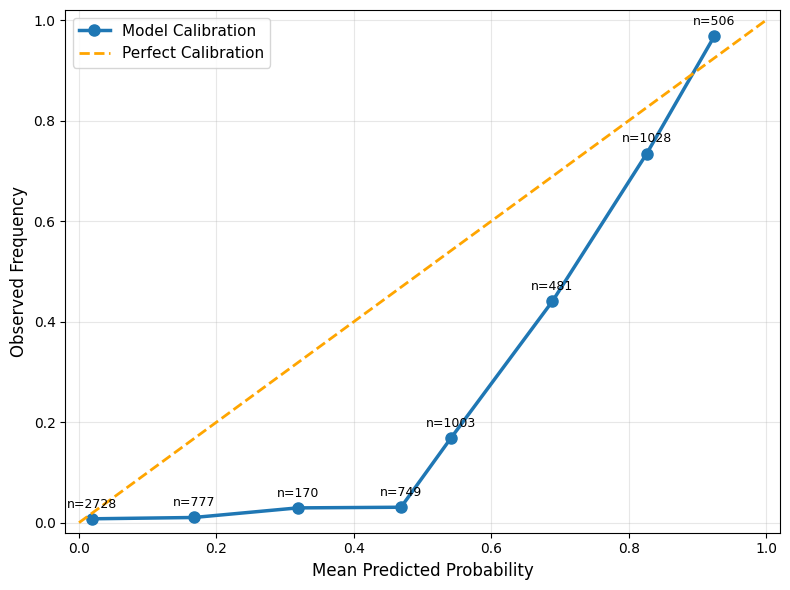

Saved: figure5_calibration_curve_final.png


In [2]:
# =========================================================
# Calibration Curve（Final Version）
# =========================================================

N_BINS = 8


# calibration curve
prob_true, prob_pred = calibration_curve(
    all_true_binary,
    all_sui_scores,
    n_bins=N_BINS,
    strategy="uniform"
)


# ============================================
# sample size of each bin
# ============================================

bin_edges = np.linspace(0, 1, N_BINS + 1)

bin_ids = np.digitize(
    all_sui_scores,
    bin_edges
) - 1


bin_counts = []

for i in range(N_BINS):

    if i == N_BINS - 1:
        mask = (
            (all_sui_scores >= bin_edges[i]) &
            (all_sui_scores <= bin_edges[i+1])
        )
    else:
        mask = (
            (all_sui_scores >= bin_edges[i]) &
            (all_sui_scores < bin_edges[i+1])
        )

    bin_counts.append(
        np.sum(mask)
    )


bin_counts = np.array(bin_counts)

valid_counts = bin_counts[
    bin_counts > 0
]


# ============================================
# plot
# ============================================

plt.figure(
    figsize=(8, 6)
)


# model calibration
plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    linewidth=2.5,
    markersize=8,
    label="Model Calibration"
)


# perfect calibration
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    color="orange",
    label="Perfect Calibration"
)


# ============================================
# annotate sample size
# ============================================

for x, y, n in zip(
        prob_pred,
        prob_true,
        valid_counts):

    plt.annotate(
        f'n={n}',
        xy=(x, y),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=9
    )


# ============================================
# metrics box
# ============================================

#plt.text(
#    0.03,
#    0.93,
#    f'Brier = {brier:.4f}',
#    transform=plt.gca().transAxes,
#    fontsize=11,
#    bbox=dict(
#        boxstyle="round",
#        facecolor="white",
#        alpha=0.9
#     )
#)


#plt.text(
#    0.03,
#    0.85,
#    f'ECE = {ece:.4f}',
#    transform=plt.gca().transAxes,
#    fontsize=11,
#    bbox=dict(
#        boxstyle="round",
#        facecolor="white",
#        alpha=0.9
#    )
#)


# ============================================
# figure style
# ============================================

plt.xlabel(
    "Mean Predicted Probability",
    fontsize=12
)

plt.ylabel(
    "Observed Frequency",
    fontsize=12
)

#plt.title(
#    "Calibration Curve (Suicidal Risk)",
#    fontsize=14
#)

plt.xlim(
    -0.02,
    1.02
)

plt.ylim(
    -0.02,
    1.02
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend(
    loc="upper left",
    fontsize=11
)

plt.tight_layout()


# ============================================
# save
# ============================================

plt.savefig(
    "figure5_calibration_curve_final.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


print(
    "Saved: figure5_calibration_curve_final.png"
)